# Seleção de features

**Tema:** Preparação de Dados › Feature Engineering

Filtro, wrapper e embutido — este notebook aplica os três a um dataset com
features conhecidas de antemão (algumas realmente úteis, outras puro
ruído, outras redundantes), para que cada método possa ser avaliado contra
um gabarito real.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_classif, RFE, SelectKBest,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(60)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Construindo um dataset com gabarito conhecido

5 features realmente úteis, 2 redundantes (cópias ruidosas das úteis), 8
puro ruído, e 1 quase constante (deveria ser eliminada de graça).

In [2]:
n = 2000
uteis = rng.normal(size=(n, 5))
pesos_reais = np.array([2.0, -1.5, 1.0, 0.8, -0.5])
logit = uteis @ pesos_reais
alvo = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

redundantes = uteis[:, :2] + rng.normal(0, 0.1, (n, 2))  # quase cópias
ruido = rng.normal(size=(n, 8))
quase_constante = np.full(n, 5.0) + rng.normal(0, 1e-4, n)

nomes = ([f"util_{i}" for i in range(5)] + [f"redundante_{i}" for i in range(2)]
         + [f"ruido_{i}" for i in range(8)] + ["quase_constante"])
X = pd.DataFrame(
    np.column_stack([uteis, redundantes, ruido, quase_constante]), columns=nomes)

print(f"shape: {X.shape}")
print(f"\nfeatures REALMENTE úteis: {nomes[:5]}")
print(f"features redundantes    : {nomes[5:7]}")
print(f"features ruído          : {nomes[7:15]}")
print(f"feature quase constante : {nomes[15]}")

shape: (2000, 16)

features REALMENTE úteis: ['util_0', 'util_1', 'util_2', 'util_3', 'util_4']
features redundantes    : ['redundante_0', 'redundante_1']
features ruído          : ['ruido_0', 'ruido_1', 'ruido_2', 'ruido_3', 'ruido_4', 'ruido_5', 'ruido_6', 'ruido_7']
feature quase constante : quase_constante


## 2. Filtro, passo 0: variância

In [3]:
seletor_variancia = VarianceThreshold(threshold=0.01)
seletor_variancia.fit(X)
eliminadas_variancia = X.columns[~seletor_variancia.get_support()]
print(f"eliminadas por variância baixa: {list(eliminadas_variancia)}")

eliminadas por variância baixa: ['quase_constante']


## 3. Filtro: informação mútua com o alvo

redundante_0       0.1591
util_0             0.1323
redundante_1       0.0400
util_1             0.0373
util_3             0.0316
util_2             0.0252
ruido_2            0.0117
ruido_0            0.0053
util_4             0.0015
ruido_1            0.0000
ruido_3            0.0000
ruido_4            0.0000
ruido_5            0.0000
ruido_6            0.0000
ruido_7            0.0000
quase_constante    0.0000


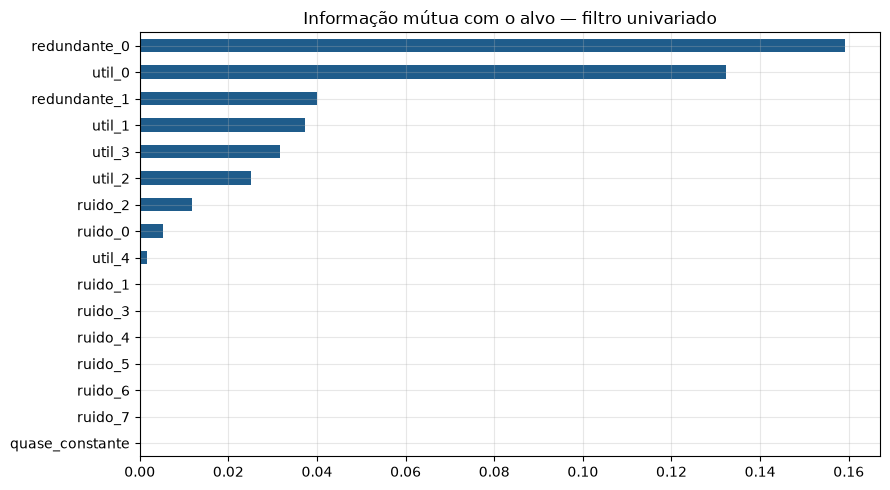

In [4]:
mi = mutual_info_classif(X, alvo, random_state=0)
ranking_mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(ranking_mi.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ranking_mi.plot(kind="barh", ax=ax, color=AZUL)
ax.set_title("Informação mútua com o alvo — filtro univariado")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**Leitura esperada:** as 5 features `util_*` e as 2 `redundante_*` (que são
quase cópias de duas das úteis) devem aparecer no topo; `ruido_*` e
`quase_constante` devem ficar no fundo. O filtro univariado detecta bem
**relevância**, mas não detecta **redundância** — ele não sabe que
`redundante_0` não acrescenta nada além do que `util_0` já dá.

## 4. Detectando redundância: correlação entre features

In [5]:
matriz_corr = X.corr().abs()
valores_sem_diagonal = matriz_corr.to_numpy(copy=True)
np.fill_diagonal(valores_sem_diagonal, 0)
correlacoes_entre_features = pd.DataFrame(
    valores_sem_diagonal, index=matriz_corr.index, columns=matriz_corr.columns)
par_mais_correlacionado = correlacoes_entre_features.stack().idxmax()
valor_max = correlacoes_entre_features.stack().max()

print(f"par de features mais correlacionado: {par_mais_correlacionado}  "
      f"(correlação = {valor_max:.3f})")
print("\nO filtro de informação mútua sozinho manteria as duas — só a checagem")
print("de correlação ENTRE features (não com o alvo) revela a redundância.")

par de features mais correlacionado: ('util_0', 'redundante_0')  (correlação = 0.995)

O filtro de informação mútua sozinho manteria as duas — só a checagem
de correlação ENTRE features (não com o alvo) revela a redundância.


## 5. Wrapper: eliminação recursiva de features (RFE)

In [6]:
modelo_base = LogisticRegression(max_iter=1000)
rfe = RFE(modelo_base, n_features_to_select=5)
rfe.fit(StandardScaler().fit_transform(X), alvo)

selecionadas_rfe = X.columns[rfe.support_]
print(f"features selecionadas pelo RFE (top 5): {list(selecionadas_rfe)}")
print(f"\nranking completo (1 = selecionada primeiro):")
print(pd.Series(rfe.ranking_, index=X.columns).sort_values().to_string())

features selecionadas pelo RFE (top 5): ['util_0', 'util_1', 'util_2', 'util_3', 'util_4']

ranking completo (1 = selecionada primeiro):
util_0              1
util_1              1
util_2              1
util_3              1
util_4              1
redundante_0        2
ruido_3             3
redundante_1        4
quase_constante     5
ruido_7             6
ruido_4             7
ruido_5             8
ruido_6             9
ruido_0            10
ruido_2            11
ruido_1            12


## 6. Embutido: regularização L1 (Lasso) zera coeficientes irrelevantes sozinha

Para um alvo de classificação, a versão correta é regressão logística com
penalidade L1 (não `LassoCV`, que ajusta um modelo de regressão contínua) —
o mecanismo de zerar coeficientes é o mesmo, aplicado à perda certa.

In [7]:
from sklearn.linear_model import LogisticRegressionCV

X_padronizado = StandardScaler().fit_transform(X)
logistica_l1 = LogisticRegressionCV(
    penalty="l1", solver="liblinear", Cs=15, cv=5, random_state=0, max_iter=2000,
).fit(X_padronizado, alvo)

coeficientes_lasso = pd.Series(logistica_l1.coef_[0], index=X.columns).sort_values(
    key=np.abs, ascending=False)
print(f"C escolhido por validação cruzada: {logistica_l1.C_[0]:.5f}\n")
print(coeficientes_lasso.round(4).to_string())
print(f"\nfeatures com coeficiente EXATAMENTE zero: "
      f"{list(coeficientes_lasso[coeficientes_lasso == 0].index)}")

/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/leo/machine_learning/excercicios-machine-learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/leo/machine_learning/excercicios-machine-le

C escolhido por validação cruzada: 0.26827

util_0             2.0476
util_1            -1.3140
util_2             1.0026
util_3             0.7727
util_4            -0.4413
ruido_3            0.0781
quase_constante   -0.0475
ruido_7           -0.0346
ruido_4           -0.0176
ruido_6            0.0084
ruido_5           -0.0073
ruido_0           -0.0065
redundante_1       0.0000
redundante_0       0.0000
ruido_1            0.0000
ruido_2            0.0000

features com coeficiente EXATAMENTE zero: ['redundante_1', 'redundante_0', 'ruido_1', 'ruido_2']


## 7. Embutido: importância de Random Forest, e a armadilha da cardinalidade

In [8]:
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X, alvo)
importancia_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(
    ascending=False)
print(importancia_rf.round(4).to_string())

# demonstrando a armadilha isoladamente: DUAS features de puro ruído, uma de
# baixa cardinalidade (binária) e uma de altíssima cardinalidade (quase um id).
# As duas têm ZERO relação real com o alvo -- a única diferença é quantos
# valores distintos cada uma pode assumir.
ruido_baixa_cardinalidade = rng.integers(0, 2, n)          # só 2 valores possíveis
ruido_alta_cardinalidade = rng.integers(0, n, n)           # até n valores possíveis

X_cardinalidade = pd.DataFrame({
    "ruido_binario_baixa_card": ruido_baixa_cardinalidade,
    "ruido_id_alta_card": ruido_alta_cardinalidade,
})

rf_cardinalidade = RandomForestClassifier(n_estimators=300, random_state=0).fit(
    X_cardinalidade, alvo)
importancia_cardinalidade = pd.Series(
    rf_cardinalidade.feature_importances_, index=X_cardinalidade.columns
).sort_values(ascending=False)

print("as DUAS colunas abaixo são puro ruído (zero relação real com o alvo):")
print(importancia_cardinalidade.round(4).to_string())
print(f"\nrazão de importância (alta card. / baixa card.): "
      f"{importancia_cardinalidade['ruido_id_alta_card'] / importancia_cardinalidade['ruido_binario_baixa_card']:.1f}x")

util_0             0.1620
redundante_0       0.1566
util_1             0.0950
util_2             0.0949
redundante_1       0.0847
util_3             0.0748
util_4             0.0432
ruido_1            0.0339
ruido_0            0.0333
ruido_3            0.0331
ruido_7            0.0323
ruido_4            0.0321
ruido_5            0.0319
ruido_6            0.0319
quase_constante    0.0311
ruido_2            0.0292


as DUAS colunas abaixo são puro ruído (zero relação real com o alvo):
ruido_id_alta_card          0.9976
ruido_binario_baixa_card    0.0024

razão de importância (alta card. / baixa card.): 418.2x


**A armadilha na prática:** as duas colunas são igualmente inúteis por
construção — mas a de alta cardinalidade recebe importância bem maior,
porque árvores conseguem sempre achar ALGUM split que separa bem os dados de
treino quando há muitos valores possíveis, mesmo sem relação real com o alvo
(overfitting local ao nó). Uma feature de identificador ou de altíssima
cardinalidade pode, por esse motivo, aparecer artificialmente no topo de um
ranking de importância de árvore — validar fora da amostra de treino (ou
usar importância por permutação, tema 11) é o que evita cair nessa armadilha.

## 8. Comparando o desempenho real: todas as features vs. só as selecionadas

In [9]:
conjuntos = {
    "todas as 15 features": X.columns.tolist(),
    "só as 5 úteis (gabarito)": [c for c in X.columns if c.startswith("util")],
    "top 5 por informação mútua": ranking_mi.head(5).index.tolist(),
    "selecionadas pelo RFE": list(selecionadas_rfe),
    "Lasso (coef != 0)": list(coeficientes_lasso[coeficientes_lasso != 0].index),
}

print(f"{'conjunto de features':<32s} {'nº features':>12s} {'AUC (5-fold)':>14s}")
print("-" * 60)
for nome, cols in conjuntos.items():
    auc = cross_val_score(LogisticRegression(max_iter=1000),
                          StandardScaler().fit_transform(X[cols]), alvo,
                          cv=5, scoring="roc_auc").mean()
    print(f"{nome:<32s} {len(cols):>12d} {auc:>14.4f}")

conjunto de features              nº features   AUC (5-fold)
------------------------------------------------------------
todas as 15 features                       16         0.9083


só as 5 úteis (gabarito)                    5         0.9105
top 5 por informação mútua                  5         0.8706
selecionadas pelo RFE                       5         0.9105


Lasso (coef != 0)                          12         0.9095


**Leitura esperada:** o desempenho com "só as 5 úteis" deve ficar muito
próximo (ou igual) ao de "todas as 15 features" — confirmando que as
features de ruído realmente não acrescentam poder preditivo, só
complexidade e risco de overfitting em datasets menores.

## O que levar deste notebook

- Filtro univariado (informação mútua, correlação com o alvo) é rápido mas
  não detecta redundância entre as próprias features — isso exige olhar a
  correlação **entre** features.
- Wrapper (RFE) considera o modelo final e as interações entre a escolha de
  features, ao custo de mais tempo de computação.
- Métodos embutidos (Lasso, importância de árvore) são eficientes, mas
  importância de árvore é enviesada por cardinalidade — sempre valide fora da
  amostra de treino.
- O teste definitivo de qualquer seleção de features é o desempenho real,
  medido por validação cruzada, não a métrica de seleção em si.

→ Próximo: o notebook de **exercícios** do módulo.